sat
[dr_001_03 = 7,
 dr_002_02 = 0,
 y_001_00 = 4,
 x_002_03 = 15,
 dr_001_01 = 1,
 dr_000_01 = 1,
 y_000_00 = 2,
 x_000_03 = 19,
 dr_001_02 = 0,
 dr_000_03 = 1,
 x_000_02 = 19,
 x_001_03 = 17,
 y_001_03 = 12,
 x_003_03 = 13,
 x_002_00 = 1,
 dr_003_01 = 2,
 dr_003_03 = 2,
 x_000_00 = 1,
 y_002_00 = 6,
 dr_000_02 = 0,
 dr_003_02 = 3,
 dr_002_01 = 1,
 dr_000_00 = 2,
 dr_002_03 = 7,
 y_003_03 = 12,
 y_000_03 = 12,
 y_003_00 = 8,
 x_003_00 = 1,
 x_001_00 = 1,
 y_002_03 = 12,
 y_003_01 = 14,
 y_003_02 = 14,
 y_001_01 = 4,
 x_002_02 = 15,
 dr_001_00 = 2,
 x_003_02 = 11,
 l_000_01 = -1,
 x_001_01 = 16,
 l_001_01 = -1,
 x_002_01 = 10,
 y_000_01 = 2,
 l_002_01 = -5,
 dr_003_00 = 1,
 y_002_01 = 6,
 y_000_02 = 3,
 l_001_02 = -7,
 l_000_02 = 9,
 x_001_02 = 17,
 y_002_02 = 11,
 l_003_02 = -2,
 l_003_01 = 4,
 l_001_00 = -15,
 x_000_01 = 18,
 l_000_00 = -17,
 x_003_01 = 7,
 l_003_00 = 6,
 l_002_02 = -1,
 l_002_00 = -9,
 y_001_02 = 5,
 dr_002_00 = 2]


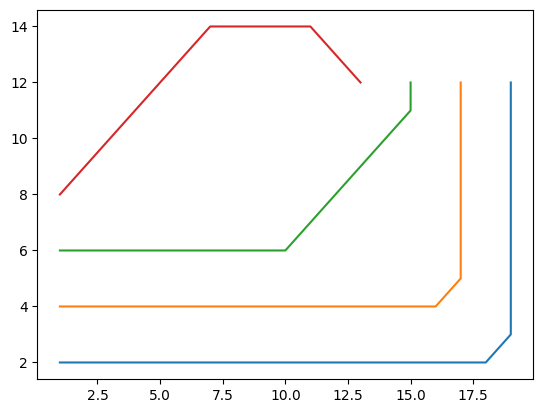

In [5]:
from matplotlib import pyplot as plt
import numpy as np
import time

import z3
z3.set_param("parallel.enable", "true")
z3.set_param("smt.arith.random_initial_value", True)
z3.set_param("memory_max_size", 4*4096)   # Setze das maximale Speicherlimit (in MB)
z3.set_param("smt.threads", 16)         # Anzahl der SMT-Solver-Threads
z3.set_param("sat.threads", 16)         # Anzahl der SAT-Solver-Threads
z3.set_param("parallel.threads.max", 16)  # Maximale Anzahl der Threads
z3.set_param("smt.random_seed", 42)     # Setze einen Seed, um die Zufälligkeit zu steuern
#z3.set_param("verbose", 10)


def bend_45(l, dr0, dr1):
    limits = z3.And(l != 0, dr0 >= 0, dr0 < 8, dr1 >= 0, dr1 < 8)
    model = dr1 == z3.If(l >= 0, dr0 + 1, dr0 - 1) % 8
    return z3.And(limits, model)

def segment(x0,y0, x1, y1, dr, l):
    labs = z3.If(l < 0, -l, l)
    limits = z3.And(dr >= 0, dr < 8)
    model = z3.If(dr==0, z3.And(x1 == x0, y1 == y0 + labs), \
            z3.If(dr==1, z3.And(x1 == x0 + labs, y1 == y0 + labs), \
            z3.If(dr==2, z3.And(x1 == x0 + labs, y1 == y0), \
            z3.If(dr==3, z3.And(x1 == x0 + labs, y1 == y0 - labs), \
            z3.If(dr==4, z3.And(x1 == x0, y1 == y0 - labs), \
            z3.If(dr==5, z3.And(x1 == x0 - labs, y1 == y0 - labs), \
            z3.If(dr==6, z3.And(x1 == x0 - labs, y1 == y0), \
            z3.If(dr==7, z3.And(x1 == x0 - labs, y1 == y0 + labs), \
            False))))))))
    return z3.And(limits, model)

def check_collision(xa, ya, dra, la, xb, yb, drb, lb):
    lacabs = z3.If(la >= 0, la, -la)
    lbcabs = z3.If(lb >= 0, lb, -lb)
    return check_collision_core(xa, ya, dra, lacabs, xb, yb, drb, lbcabs)

def check_collision_core(xa, ya, dra, la, xb, yb, drb, lb):
    xd = xb - xa
    yd = yb - ya
    drd = (drb - dra) % 8
    xt4 = z3.If((dra / 4) % 2 == 1, -xd, xd)
    yt4 = z3.If((dra / 4) % 2 == 1, -yd, yd)
    xt2 = z3.If((dra / 2) % 2 == 1, -yt4, xt4)
    yt2 = z3.If((dra / 2) % 2 == 1, xt4, yt4)
    xt = z3.If(dra % 2 == 1, xt2 - yt2, xt2)
    yt = z3.If(dra % 2 == 1, yt2 + xt2, yt2)
    lat = z3.If(dra % 2 == 1, 2 * la, la)
    lbt = z3.If(dra % 2 == 1, 2 * lb, lb)
    
    limits = z3.And(drd >= 0, dra >= 0, dra < 8, drb >= 0, drb < 8)   
    collision = z3.If(drd==0, z3.If(xt == 0, z3.If(yt <= 0, lbt >= -yt, yt <= lat), False), \
           z3.If(drd==1, z3.If(yt - xt >= 0, z3.If(yt - xt <= lat, z3.If(xt <= 0, lbt >= -xt , False), False), False), \
           z3.If(drd==2, z3.If(yt >= 0, z3.If(yt <= lat, z3.If(xt <= 0, lbt >= -xt , False), False), False), \
           z3.If(drd==3, z3.If(yt + xt >= 0, z3.If(yt + xt <= lat, z3.If(xt <= 0, lbt >= -xt , False), False), False), \
           z3.If(drd==4, z3.If(xt == 0, z3.If(yt <= 0, False, yt <= lat + lbt), False), \
           z3.If(drd==5, z3.If(yt - xt >= 0, z3.If(yt - xt <= lat, z3.If(xt >= 0, lbt >= xt , False), False), False), \
           z3.If(drd==6, z3.If(yt >= 0, z3.If(yt <= lat, z3.If(xt >= 0, lbt >= xt , False), False), False), \
           z3.If(drd==7, z3.If(yt + xt >= 0, z3.If(yt + xt <= lat, z3.If(xt >= 0, lbt >= xt , False), False), False), \
           False))))))))
    return z3.And(limits, z3.Not(collision))

def z3extract(z3model, z3vars):
    if isinstance(z3vars, list):
        return [z3model[e].as_long() for e in z3vars]
    else:
        return z3model[z3vars].as_long()

def declare_all_traces(nbr_traces=3, nbr_segments=5):
    return [[[z3.Int(f"x_{p:03}_{s:02}"),
              z3.Int(f"y_{p:03}_{s:02}"),
              z3.Int(f"dr_{p:03}_{s:02}"),
              z3.Int(f"l_{p:03}_{s:02}")] for s in range(nbr_segments)] for p in range(nbr_traces)]

def create_all_segment_constraints(traces):
     return [segment(trace[i][0], trace[i][1], trace[i+1][0], trace[i+1][1], trace[i][2], trace[i][3]) for trace in traces for i in range(len(trace)-1)]
   
def create_all_bend_constraints(traces):
    return [bend_45(trace[i][3], trace[i][2], trace[i+1][2]) for trace in traces for i in range(len(trace)-1)]

def create_all_collision_constraints(traces):
    return [check_collision(traces[ita][isa][0],traces[ita][isa][1],traces[ita][isa][2],traces[ita][isa][3],
                            traces[itb][isb][0],traces[itb][isb][1],traces[itb][isb][2],traces[itb][isb][3]) \
        for ita in range(len(traces)) for itb in range(ita,len(traces)) for isa in range(len(traces[ita])-1) for isb in range(len(traces[itb])-1) if ita != itb]




traces = declare_all_traces(4,4)
segment_constraints = create_all_segment_constraints(traces)
bend_constraints = create_all_bend_constraints(traces)
collision_constraints = create_all_collision_constraints(traces)

endpoint_constraints = [traces[0][0][0] == 1, traces[0][0][1] == 2, traces[0][-1][0] == 19, traces[0][-1][1] == 12,# traces[0][0][2] == 2, traces[1][2][2] == 0,
                        traces[1][0][0] == 1, traces[1][0][1] == 4, traces[1][-1][0] == 17, traces[1][-1][1] == 12,# ],
                        traces[2][0][0] == 1, traces[2][0][1] == 6, traces[2][-1][0] == 15, traces[2][-1][1] == 12,
                        traces[3][0][0] == 1, traces[3][0][1] == 8, traces[3][-1][0] == 13, traces[3][-1][1] == 12]

s = z3.Solver()
s.add(*bend_constraints,*segment_constraints,*endpoint_constraints, *collision_constraints)

print(s.check())
m = s.model()
print(m)

traces_plot = [z3extract(m, [segment[d] for segment in trace]) for trace in traces for d in [0,1]]


from matplotlib import pyplot as plt

#plt.plot(xapv, yapv, xbpv, ybpv)
plt.plot(*traces_plot)

plt.show()

In [94]:
# tests

s = z3.Solver()
s.add(check_collision(0,0,0,0,0,0,0,0))
print(s.check())
s = z3.Solver()
s.add(check_collision(0,0,0,4,1,1,7,2))
print(s.check())




unsat
unsat


In [4]:
sat
[dr_001_05 = 0,
 dr_001_03 = 0,
 dr_002_02 = 7,
 y_001_00 = 4,
 dr_001_04 = 1,
 dr_001_01 = 2,
 dr_000_01 = 4,
 dr_003_04 = 2,
 y_000_00 = 2,
 dr_001_02 = 1,
 x_000_02 = 4,
 dr_000_03 = 2,
 y_002_05 = 12,
 y_000_05 = 12,
 x_002_00 = 1,
 y_003_05 = 12,
 dr_003_01 = 5,
 dr_003_05 = 1,
 dr_003_03 = 3,
 x_000_00 = 1,
 y_001_05 = 12,
 y_002_00 = 6,
 x_002_05 = 15,
 dr_000_02 = 3,
 dr_003_02 = 4,
 dr_002_01 = 6,
 x_001_04 = 17,
 dr_002_03 = 0,
 x_000_05 = 19,
 dr_000_04 = 1,
 dr_000_05 = 0,
 dr_002_04 = 1,
 dr_002_05 = 2,
 x_003_00 = 1,
 x_001_00 = 1,
 y_003_00 = 8,
 x_001_05 = 17,
 x_003_05 = 13,
 dr_001_00 = 3,
 l_003_00 = 9,
 y_002_03 = 11,
 x_000_01 = 1,
 l_000_03 = -1,
 l_003_04 = -15,
 l_000_04 = -21,
 l_001_04 = -4,
 x_001_02 = 16,
 y_001_01 = 4,
 l_002_04 = 32,
 l_000_00 = 9,
 l_000_02 = -14,
 y_002_01 = 6,
 l_001_02 = -2,
 x_003_04 = -2,
 l_003_02 = -1,
 dr_003_00 = 4,
 x_001_01 = 15,
 y_003_02 = -2,
 l_002_00 = 16,
 x_001_03 = 16,
 x_003_03 = -7,
 y_001_04 = 8,
 x_002_02 = -18,
 y_001_03 = 7,
 y_000_02 = -10,
 y_002_02 = 9,
 x_002_03 = -18,
 dr_000_00 = 3,
 x_000_03 = 18,
 y_000_04 = -9,
 y_001_02 = 5,
 y_000_01 = -7,
 x_000_04 = 19,
 l_003_01 = -1,
 x_003_02 = -8,
 y_003_04 = -3,
 y_002_04 = 12,
 l_001_03 = 1,
 l_002_02 = 2,
 l_003_03 = -5,
 x_003_01 = -8,
 x_002_01 = -15,
 y_003_01 = -1,
 l_000_01 = -3,
 y_000_03 = -10,
 l_001_01 = -1,
 l_002_01 = 3,
 l_002_03 = 1,
 dr_002_00 = 5,
 y_003_03 = -3,
 l_001_00 = -14,
 x_002_04 = -17]

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (346671386.py, line 2)

In [ ]:

lv = [3, 3, 3, 3,3,3,4,4,4,4,4,4,-4,-4,-4,-4,-4,-3,-3,-3,-3]
p0 = (0,0)
p = p0
pltv = [p0]
dr0 = 0
dr = dr0
for e in lv:
    dr = (dr + np.sign(e)) & 7
    l = np.abs(e)
    slct = [(p[0], p[1] + l),
            (p[0] + l, p[1] + l),
            (p[0] + l, p[1]),
            (p[0] + l, p[1] - l),
            (p[0], p[1] - l),
            (p[0] - l, p[1] - l),
            (p[0] - l, p[1]),
            (p[0] - l, p[1] + l)]
    p = slct[dr]
    pltv.append(p)

print(pltv)
pltv2 = [[e[0] for e in pltv], [e[1] for e in pltv]]
plt.plot(pltv2[0], pltv2[1])

plt.show()



In [1]:
xa = z3.Int("xa")
ya = z3.Int("ya")
dra = z3.Int("dra")
la = z3.Int("la")
xb = z3.Int("xb")
yb = z3.Int("yb")
drb = z3.Int("drb")
lb = z3.Int("lb")

xb = 1
yb = 3
drb = 4
lb = 7

check_collision(xa, ya, dra, la, xb, yb, drb, lb)
s = z3.Solver()
s.add(check_collision(xa, ya, dra, la, xb, yb, drb, lb))
print(s.check())
m = s.model()
print(m)

NameError: name 'z3' is not defined

In [ ]:
xap = [z3.Int("xa0"), z3.Int("xa1"), z3.Int("xa2"), z3.Int("xa3"), z3.Int("xa4"), z3.Int("xa5")]
yap = [z3.Int("ya0"), z3.Int("ya1"), z3.Int("ya2"), z3.Int("ya3"), z3.Int("ya4"), z3.Int("ya5")]
drap = [z3.Int("drap0"), z3.Int("drap1"),z3.Int("drap2"),z3.Int("drap3"),z3.Int("drap4"),z3.Int("drap5")]
lap = [z3.Int("la0"), z3.Int("la1"), z3.Int("la2"), z3.Int("la3"), z3.Int("la4")]

bendsa = [bend_45(lap[i], drap[i], drap[i+1]) for i in range(len(lap))]
segmentsa = [segment(xap[i], yap[i], xap[i+1], yap[i+1], drap[i+1], lap[i]) for i in range(len(lap))]


xbp = [z3.Int("xb0"), z3.Int("xb1"), z3.Int("xb2"), z3.Int("xb3"), z3.Int("xb4"), z3.Int("xb5")]
ybp = [z3.Int("yb0"), z3.Int("yb1"), z3.Int("yb2"), z3.Int("yb3"), z3.Int("yb4"), z3.Int("yb5")]

lbp = [z3.Int("lb0"), z3.Int("lb1"), z3.Int("lb2"), z3.Int("lb3"), z3.Int("lb4")]
drbp = [z3.Int("drbp0"), z3.Int("drbp1"),z3.Int("drbp2"),z3.Int("drbp3"),z3.Int("drbp4"),z3.Int("drbp5")]

bendsb = [bend_45(lbp[i], drbp[i], drbp[i+1]) for i in range(len(lbp))]
segmentsb = [segment(xbp[i], ybp[i], xbp[i+1], ybp[i+1], drbp[i+1], lbp[i]) for i in range(len(lbp))]

collisions = [check_collision(xap[ia],yap[ia],drap[ia+1],lap[ia],xbp[ib],ybp[ib],drbp[ib+1],lbp[ib]) for ia in range(len(lap)) for ib in range(len(lbp))]

endptsa = [xap[0] == 3, yap[0] == 6, xap[-1] == 19, yap[-1] == 22]
endptsb = [xbp[0] == 1, ybp[0] == 17, xbp[-1] == 15, ybp[-1] == 2]


#s.add(*bendsa,*segmentsa,*endptsa,*bendsb,*segmentsb,*endptsb,*collisions)

xapv = z3extract(m, [segment[0] for segment in traces[0]])
yapv = z3extract(m, [segment[1] for segment in traces[0]])
xbpv = z3extract(m, [segment[0] for segment in traces[1]])
ybpv = z3extract(m, [segment[1] for segment in traces[1]])
